# LeetCode #12: Integer to Roman



https://leetcode.com/problems/integer-to-roman/



## Comparison of Approaches



| Approach | Time Complexity | Space Complexity |

| :--- | :--- | :--- |

| **Brute Force: Digit-by-Digit** | $O(1)$ | $O(1)$ |

| **Optimal: Greedy Symbol Table** ★ | $O(1)$ | $O(1)$ |



---



## Understanding the Methods



### Brute Force: Digit-by-Digit

Extract each decimal digit (thousands, hundreds, tens, ones) and look it up in a separate hardcoded table for that place value. Works, but requires four independent lookup arrays and four concatenations.



### Optimal: Greedy Symbol Table ★

Maintain one ordered list of all 13 (value, symbol) pairs — including the six subtractive forms (CM, CD, XC, XL, IX, IV). Greedily subtract the largest fitting value and append its symbol until `num` reaches zero.



**Why this is better than Digit-by-Digit:** Same $O(1)$ time and space (num is bounded by 3999, so at most ~15 symbol appends). A single unified loop is simpler to read, extend, and verify than four separate lookup tables.



**Constraints:**

* `1 <= num <= 3999`

## Solutions



### C#

In [ ]:
public class Solution {

    public string IntToRoman(int num) {

        int[] values     = { 1000, 900, 500, 400, 100, 90, 50, 40, 10, 9, 5, 4, 1 };

        string[] symbols = { "M", "CM", "D", "CD", "C", "XC", "L", "XL", "X", "IX", "V", "IV", "I" };

        var result = new System.Text.StringBuilder();

        for (int i = 0; i < values.Length; i++) {

            // Append this symbol as many times as it fits

            while (num >= values[i]) {

                result.Append(symbols[i]);

                num -= values[i];

            }

        }

        return result.ToString();

    }

}

### Python

In [ ]:
class Solution:

    def intToRoman(self, num: int) -> str:

        values  = [1000, 900, 500, 400, 100, 90, 50, 40, 10, 9, 5, 4, 1]

        symbols = ["M", "CM", "D", "CD", "C", "XC", "L", "XL", "X", "IX", "V", "IV", "I"]

        result = []

        for value, symbol in zip(values, symbols):

            # Append this symbol as many times as it fits

            while num >= value:

                result.append(symbol)

                num -= value

        return "".join(result)

### Go

In [ ]:
import "strings"



func intToRoman(num int) string {

    values  := []int{1000, 900, 500, 400, 100, 90, 50, 40, 10, 9, 5, 4, 1}

    symbols := []string{"M", "CM", "D", "CD", "C", "XC", "L", "XL", "X", "IX", "V", "IV", "I"}

    var result strings.Builder

    for i, value := range values {

        // Append this symbol as many times as it fits

        for num >= value {

            result.WriteString(symbols[i])

            num -= value

        }

    }

    return result.String()

}

### Rust

In [ ]:
impl Solution {

    pub fn int_to_roman(num: i32) -> String {

        let values  = [1000, 900, 500, 400, 100, 90, 50, 40, 10, 9, 5, 4, 1];

        let symbols = ["M", "CM", "D", "CD", "C", "XC", "L", "XL", "X", "IX", "V", "IV", "I"];

        let mut result = String::new();

        let mut num = num;

        for (&value, &symbol) in values.iter().zip(symbols.iter()) {

            // Append this symbol as many times as it fits

            while num >= value {

                result.push_str(symbol);

                num -= value;

            }

        }

        result

    }

}

## Example Scenarios



**Example 1 — Common Case**\

**Input:** `num = 3749`\

M×3 consumes 3000, D consumes 500, C×2 consumes 200, XL consumes 40, IX consumes 9. The algorithm visits each of the 13 table entries in order and uses the inner `while` for repeated symbols → **"MMMDCCXLIX"**.



**Example 2 — Slightly Complex**\

**Input:** `num = 58`\

The first six entries (1000–90) are all larger than 58 and are skipped instantly. L(50) appends once, then V(5) once, then I(1) three times → **"LVIII"**.



**Example 3 — Edge Case: Time Factor**\

**Input:** `num = 3888`\

3888 = 3000+500+300+80+8 produces M×3, D, C×3, L, X×3, V, I×3 — the longest possible Roman numeral output at 15 characters, and the maximum number of symbol-append operations the algorithm can perform → **"MMMDCCCLXXXVIII"**.



**Example 4 — Edge Case: Space Factor**\

**Input:** `num = 1`\

Minimum input: entries 1–12 are all skipped (all > 1), I appends once. Only two variables (`result`, loop index `i`) plus the two fixed arrays — proves $O(1)$ auxiliary space at both extremes of the input range → **"I"**.



**Example 5 — Almost-Impossible but Plausible**\

**Input:** `num = 1994`\

1994 = 1000+900+90+4: M(1000) → CM(900) → XC(90) → IV(4). Three of the six subtractive pairs fire in sequence. Without explicit subtractive entries in the table, each would be wrong (e.g., DCCCC instead of CM) → **"MCMXCIV"**.

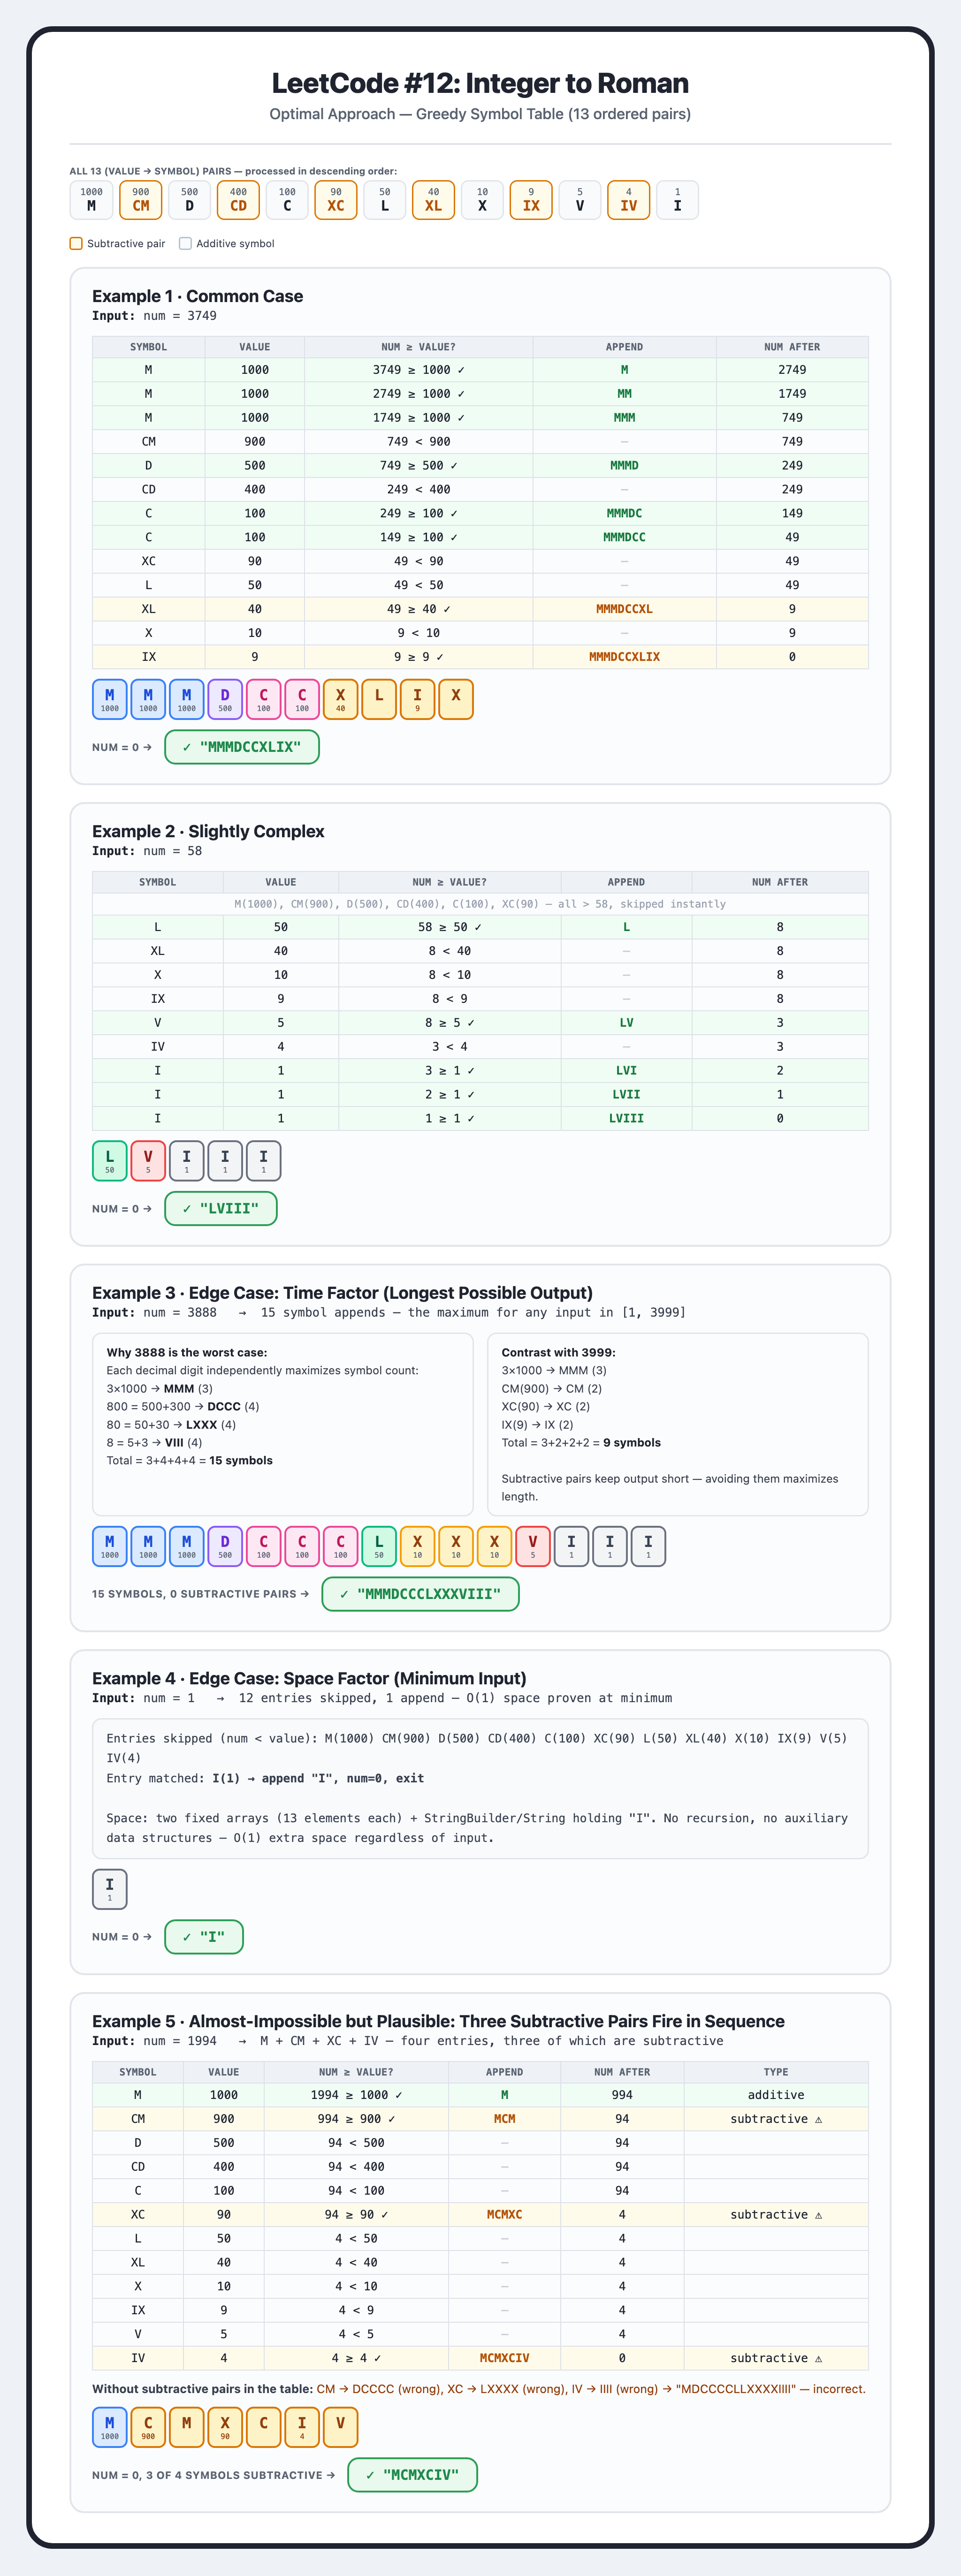